In [ ]:
from pathlib import Path

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel/UDELData")
udel_subj = udel_dir/f"U01_UDEL_{subid}_01_v3"
udel_anatomy = udel_subj/f"U01_UDEL_{subid}_01_SLANT"
fs_dir = udel_dir / "fsruns" / subid
mre_dir = Path("/home/oana/MRE_analysis") / subid


# MRE volumes
mre_files = {
    "stiffness": mre_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": mre_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": mre_dir / "MRE_imag_in_T1_space.nii.gz",
}
t1_path=fs_dir/"mri/T1.mgz"
# T1W and T2w paths for later myelin calculation
t1w_path = udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_deface.nii.gz"
t2w_path = udel_anatomy/f"U01_UDEL_{subid}_01_3DT2_norm.nii.gz"

In [ ]:
import numpy as np
import nibabel as nib
from cortech import Cortex
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

cortex = Cortex.from_freesurfer_subject_dir(fs_dir, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
#for hemi in [cortex.lh, cortex.rh]:
#    hemi.white.smooth_taubin(n_iter=5, inplace=True)
#    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


#mask_img = nib.load(str(brainmask_dir))
#mask_data = mask_img.get_fdata()
#mask_affine = mask_img.affine

#surface_brainmask = {hemi: mid_layers[hemi].interpolate_to_nodes(mask_data, mask_affine) for hemi in ["lh","rh"]}

#surface_brainmask = {hemi: surface_brainmask[hemi] > 0.5 for hemi in ["lh","rh"]}

# interpolate all MRE data
surface_mre = {}

for name, vol_path in mre_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_mre[name] = {hemi: mid_layers[hemi].interpolate_to_nodes(data, affine) for hemi in ["lh", "rh"]}


# Myelin map
t1_img = nib.load(str(t1w_path))
t2_img = nib.load(str(t2w_path))
#mask_img = nib.load(str(brainmask_path))

t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()
#mask_data = mask_img.get_fdata().astype(bool)

t1_affine = t1_img.affine


#t1_masked = np.where(mask_data, t1_data, np.nan)
#t2_masked = np.where(mask_data, t2_data, np.nan)

#compute ratio only there both images arep positive
valid = (t1_data > 0) & (t2_data > 0)
myelin_data = np.where(valid, t1_data/(t2_data + 1e-3), 0)

# Interpolate myelin map to surface
surface_myelin = {hemi: mid_layers[hemi].interpolate_to_nodes(myelin_data, t1_affine) for hemi in ["lh", "rh"]}


# Regions 
#region_img = nib.load(str(regions_path))
#region_data = region_img.get_fdata().astype(int)
#region_affine = region_data.affine
#surface_regions = {hemi: mid_layers[hemi].interpolate_to_nodes(region_data, region_affine, method ="nearest").astype(int) for hemi in ["lh", "rh"]}

#Load parcellation
aparc = {
    "lh": nib.freesurfer.io.read_annot(fs_dir / "label" / "lh.aparc.a2009s.annot"),
    "rh": nib.freesurfer.io.read_annot(fs_dir / "label" / "rh.aparc.a2009s.annot"),
}


#Add geometry parameters

from nibabel.freesurfer import read_morph_data

curvature = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.curv"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.curv"),
}
#lh.inflated.K
#lh.inflated.H

thickness = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.thickness"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.thickness"),
}

sulcal_depth = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.sulc"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.sulc"),
}


In [11]:
import pandas as pd

stiff_min=99 

for hemi in ["lh","rh"]:
    labels, ctab, names = aparc[hemi]
    labels = labels.astype(int)

    #Extract hemi specific arrays
    curv = curvature[hemi].astype(np.float64)
    thick= thickness[hemi].astype(np.float64)
    stiff = surface_mre["stiffness"][hemi].astype(np.float64)
    real = surface_mre["real"][hemi].astype(np.float64) #shear real (storage modulus)
    imag = surface_mre["imag"][hemi].astype(np.float64) #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi].astype(np.float64)
    myelin = surface_myelin[hemi].astype(np.float64)

    #Stiffness mask that eliminates values around zero
    stiff_mask=(np.isfinite(stiff) & (stiff >= stiff_min))

    #Apply the mask to the other 
    curv_m=curv[stiff_mask]
    thick_m=thick[stiff_mask]
    stiff_m = stiff[stiff_mask]
    real_m =real[stiff_mask]
    imag_m = imag[stiff_mask]
    sulc_m =sulc[stiff_mask]
    myelin_m=myelin[stiff_mask]
    labels_m=labels[stiff_mask]

    names= np.array([n.decode("utf-8") for n in names])
    #Transform shear stiffness, storage modulus and loss modulus to kPa
    stiff_kpa = stiff_m/1000
    real_kpa = real_m/1000
    imag_kpa = imag_m/1000

    #Create a DataFrame 
    df = pd.DataFrame({
        "curvature":curv_m,
        "thickness":thick_m,
        "sulcal_depth":sulc_m,
        "stiffness":stiff_kpa,
        "real":real_kpa,
        "imag":imag_kpa,
        "myelin":myelin_m,
        "label":labels_m,
    })

    df["parcel"]=df["label"].map({i:names[i] for i in range(len(names))})
df.head()


,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin,label,parcel
0,-0.076381,2.733513,-4.104676,0.149998,0.126377,0.064278,0.566279,43,Pole_occipital
1,-0.109680,2.197700,-5.186806,0.108453,0.068527,0.064107,0.481647,43,Pole_occipital
2,-0.317661,2.030369,-6.008362,0.130512,0.094126,0.070193,0.572864,43,Pole_occipital
3,-0.274947,2.255861,-6.151323,0.101734,0.069711,0.057153,0.690901,43,Pole_occipital
4,-0.044668,2.824182,-3.661626,0.251696,0.207358,0.113128,0.571042,43,Pole_occipital


In [30]:
from scipy.stats import spearmanr
results=[]

for parcel, g in df.groupby("parcel"):
    if len(g)<50:
        continue

    r,p=spearmanr(g["stiffness"],g["curvature"],nan_policy="omit")

    results.append({
        "parcel":parcel,
        "n_vertices":len(g),
        "r_val":r,
        "p_val":p
    })

parcel_stats=pd.DataFrame(results)
parcel_stats.sort_values("r_val",ascending=True)

,parcel,n_vertices,r_val,p_val
2,G_and_S_cingul-Mid-Ant,1698,-0.256630,6.082766e-27
69,S_suborbital,533,-0.212847,7.073029e-07
43,S_calcarine,2568,-0.197879,4.368897e-24
4,G_and_S_frontomargin,1061,-0.136689,7.891207e-06
11,G_cuneus,2510,-0.131795,3.389741e-11
...,...,...,...,...
13,G_front_inf-Orbital,510,0.625213,1.158302e-56
22,G_occipital_sup,1720,0.648621,6.317202e-206
32,G_temp_sup-G_T_transv,433,0.652551,6.963936e-54
55,S_intrapariet_and_P_trans,3267,0.666123,0.000000e+00


In [23]:
from statsmodels.stats.multitest import multipletests

parcel_stats["p_fdr"]=multipletests(parcel_stats["p_val"],method="fdr_bh")[1]
parcel_stats.sort_values("p_fdr",ascending=True)

,parcel,n_vertices,r_val,p_val,p_fdr,abs_r
26,G_parietal_sup,2572,-0.562257,2.430539e-214,1.798599e-212,0.562257
45,S_cingul-Marginalis,1661,0.600449,2.728924e-163,1.009702e-161,0.600449
37,G_temporal_middle,3370,-0.423571,7.893881e-147,1.947157e-145,0.423571
15,G_front_middle,4302,-0.324414,5.466275e-106,1.011261e-104,0.324414
34,G_temp_sup-Plan_polar,1332,-0.536693,3.108038e-100,4.599897e-99,0.536693
...,...,...,...,...,...,...
39,Lat_Fis-ant-Vertical,227,-0.065809,3.235855e-01,3.420761e-01,0.065809
72,S_temporal_sup,8095,-0.008669,4.354524e-01,4.538518e-01,0.008669
18,G_oc-temp_lat-fusifor,1790,0.010123,6.686608e-01,6.872347e-01,0.010123
12,G_front_inf-Opercular,1541,0.010304,6.860746e-01,6.954729e-01,0.010304


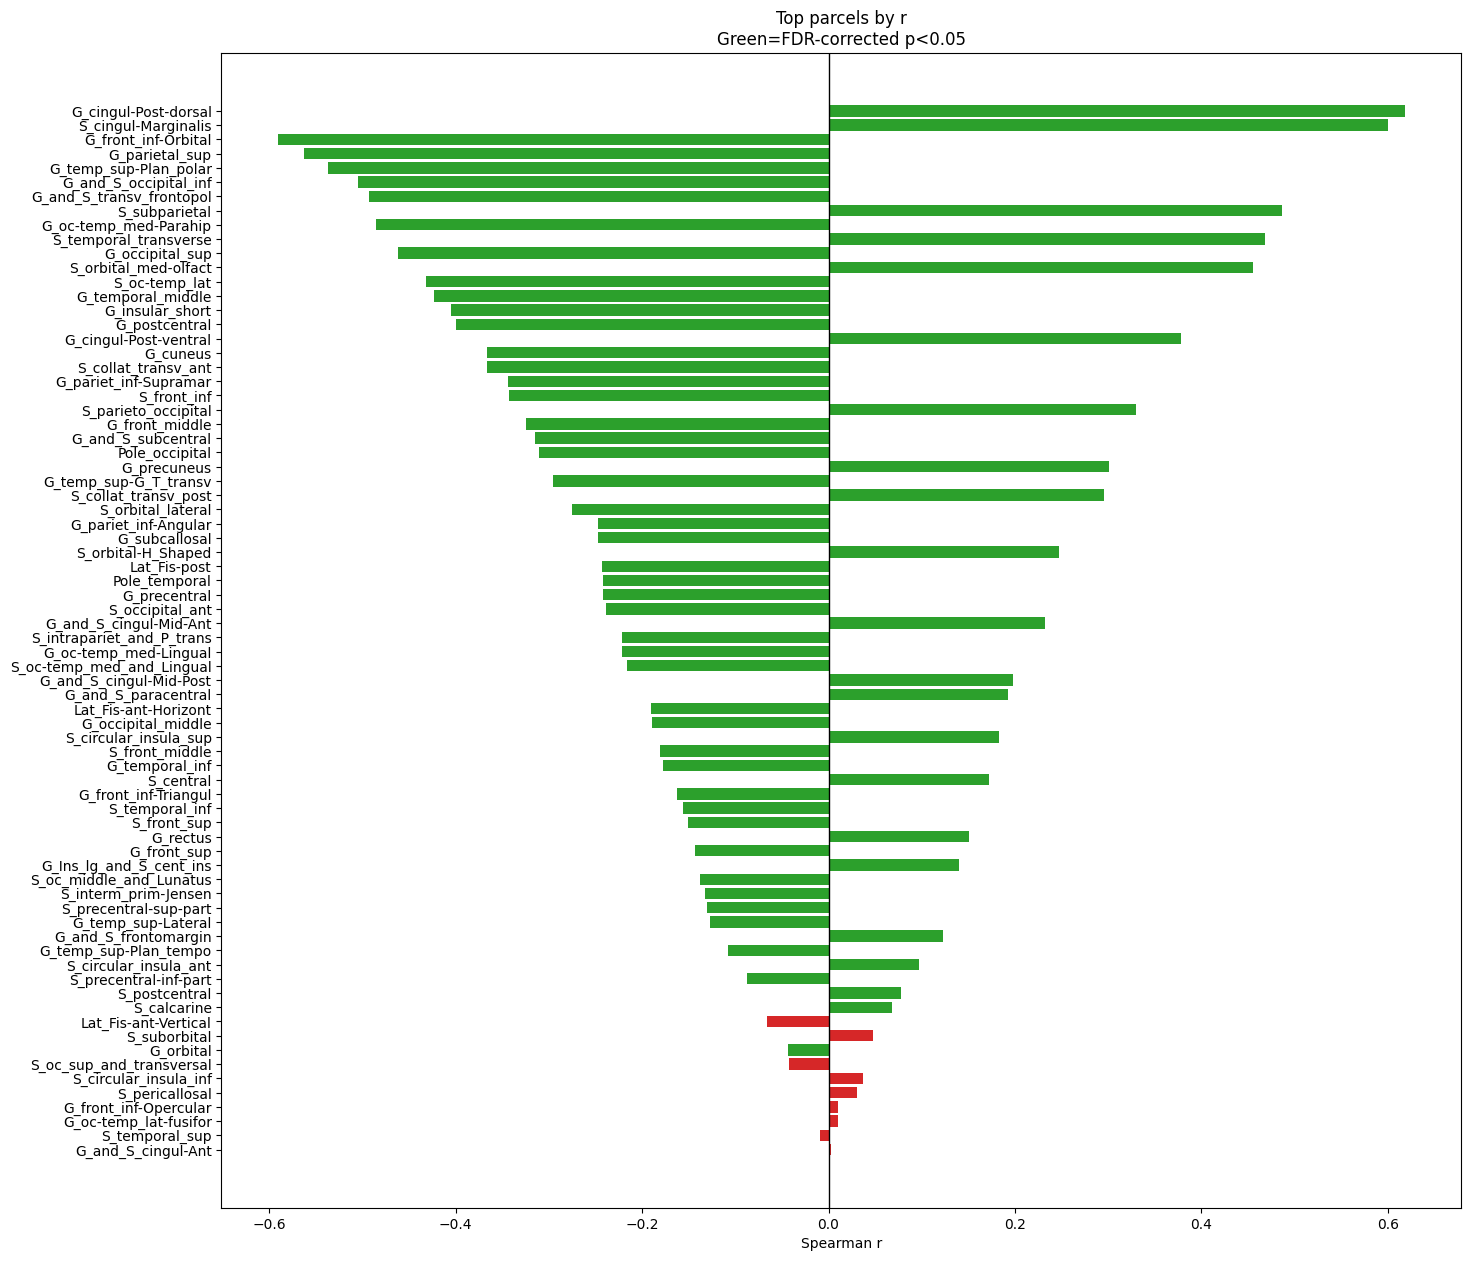

In [29]:
parcel_stats["abs_r"]=parcel_stats["r_val"].abs()
top=parcel_stats.sort_values("abs_r",ascending=False).head(74)
colors=["tab:green" if p<0.05 else "tab:red" for p in top["p_fdr"]]

plt.figure(figsize=(16,15))
plt.barh(top["parcel"],top["r_val"], color=colors)
plt.axvline(0,color="k",lw=1)
plt.xlabel("Spearman r")
plt.title("Top parcels by r\nGreen=FDR-corrected p<0.05")
plt.gca().invert_yaxis()
plt.show()